---
tags: [algorithm, primitive, resource-estimation]
---

# 量子フーリエ変換（QFT）入門

量子フーリエ変換（QFT）は、離散フーリエ変換の量子版です。量子位相推定や位数発見など、量子振幅に埋め込まれた位相情報を使うアルゴリズムで、重要なサブルーチンとして使われます{cite:p}`10.48550/arXiv.quant-ph/0201067`。

このノートブックでは、古典のフーリエ変換から始めてQFT回路を説明し、4量子ビットの周波数推定の例をQamomileで実装します。QFT回路の描画、ローカルのQiskitシミュレータでの実行、ヒストグラムからの周波数推定、計算量のスケーリングの確認までを扱います。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

import qamomile.circuit as qmc
from qamomile.circuit.stdlib.qft import qft
from qamomile.qiskit import QiskitTranspiler
from qiskit_aer import AerSimulator

transpiler = QiskitTranspiler()

## 背景: フーリエ変換

フーリエ変換は、データを周波数の成分として書き直します。どの周波数がどれだけ含まれているかを調べる方法です。有限長のベクトルに対してよく使うのが**離散フーリエ変換**（Discrete Fourier Transform、DFT）です。

ベクトル$x = (x_0, x_1, \ldots, x_{N-1})$に対して、このノートブックでは次の正規化を使います。

$$
y_k = \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1} x_j e^{2\pi i jk / N},
\qquad k = 0, 1, \ldots, N-1.
$$

出力の添字$k$は周波数を表します。位相因子$e^{2\pi i jk / N}$により、入力の各位置が異なる位相で足し合わされます。

## アルゴリズム

QFTは、同じ変換を量子状態の振幅に適用します。$N = 2^n$のとき、基底状態$\lvert x\rangle$への作用は次の通りです。

$$
\mathrm{QFT}_N \lvert x \rangle =
\frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i xk/N}\lvert k \rangle.
$$

古典のDFTでは、出力ベクトル全体を得られます。一方、QFTは量子状態の振幅を変換します。QFTの直後に測定しても、得られるのはサンプルだけです。ただし、位相推定のように、後続の量子演算では変換後の位相情報を利用できます。

標準的なQFT回路は、アダマールゲート、制御付き位相回転、最後のスワップで構成されます。$n$量子ビットのレジスタでは、密な$2^n \times 2^n$行列を直接使うのではなく、$O(n^2)$個のゲートで実装できます。位相を表すために、次の2進小数表記を使います。

$$
[0.x_jx_{j+1}\ldots x_n] =
\frac{x_j}{2}
+ \frac{x_{j+1}}{2^2}
+ \cdots
+ \frac{x_n}{2^{n-j+1}}
=
\sum_{m=j}^{n} \frac{x_m}{2^{m-j+1}}.
$$

### ステップ1：対象量子ビットを1つ選ぶ

レジスタを対象量子ビットごとに処理します。最後の量子ビットにアダマールゲートを適用すると、QFTの出力に現れる最初の因子が得られます。

$$
\lvert x_n\rangle
\xrightarrow{H}
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_n]}\lvert 1\rangle\right).
$$

### ステップ2：制御付き位相回転を加える

残りの量子ビットからの制御付き位相回転により、2進小数に必要なビットが加わります。対象量子ビット$x_j$に対して、アダマールゲートと制御付き位相回転は次の状態を作ります。

$$
\lvert x_j\rangle
\longmapsto
\frac{1}{\sqrt{2}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

この位相回転は、一般に$R_k$として次のように書きます。

$$
R_k =
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi i / 2^k}
\end{pmatrix}.
$$

制御付き$R_k$は、制御量子ビットが$\lvert 1\rangle$のときだけ対象量子ビットにこの回転を適用します。制御位置と対象位置の距離を$d$とすると、QFT回路では制御付き$R_{d+1}$を使います。その回転角は次の通りです。

$$
\theta = \frac{2\pi}{2^{d+1}} = \frac{\pi}{2^d}.
$$

### ステップ3：レジスタ全体で繰り返す

アダマールゲートと制御付き位相回転のパターンを繰り返すと、QFTは次の積の形で書けます。

$$
\mathrm{QFT}\lvert x_1x_2\ldots x_n\rangle =
\frac{1}{\sqrt{2^n}}
\bigotimes_{j=n}^{1}
\left(\lvert 0\rangle + e^{2\pi i[0.x_jx_{j+1}\ldots x_n]}\lvert 1\rangle\right).
$$

4量子ビットの場合は次のようになります。

$$
\mathrm{QFT}\lvert x_1x_2x_3x_4\rangle =
\frac{1}{\sqrt{16}}
\left(\lvert 0\rangle + e^{2\pi i[0.x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_3x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_2x_3x_4]}\lvert 1\rangle\right)
\otimes
\left(\lvert 0\rangle + e^{2\pi i[0.x_1x_2x_3x_4]}\lvert 1\rangle\right).
$$

### ステップ4：出力順序を反転する

標準的なQFT回路では、出力量子ビットの順序が逆になります。最後にスワップ層を置くことで、レジスタの順序を戻します。一部のアルゴリズムではこのスワップを省き、逆順であることを古典側で管理します。

```{figure} assets/qft_circuit.png
:alt: 標準QFT回路
:width: 720px

n=4のときのQFTの量子回路。
```

## Qamomileでの実装：`qft`関数

`qamomile.circuit.stdlib.qft.qft`関数は、上で説明した回路を適用します。アダマールゲート、制御付き位相回転、最後のスワップをまとめて扱えます。

### 問題例

$N=16$個のサンプルを使うので、4量子ビットで表せます。この例では$n=4$、$N=16$、$\omega = e^{2\pi i/16}$であり、次のように書けます。

$$
F_{16}\lvert x \rangle =
\frac{1}{\sqrt{16}}\sum_{k=0}^{15}\omega^{xk}\lvert k\rangle.
$$

ここでは、基底状態$\lvert j\rangle$の振幅を$s_j$とする量子状態を準備します。

$$
\lvert \psi_f\rangle =
\sum_{j=0}^{N-1} s_j \lvert j\rangle,
\qquad
s_j = \frac{1}{\sqrt{N}} e^{-2\pi i f j/N},
\qquad f=5,\quad j=0,1,\ldots,N-1.
$$

つまり、$e^{-2\pi i f j/N}$の値を、正規化係数$1/\sqrt{N}$付きで$\lvert \psi_f\rangle$の振幅に埋め込んでいます。この状態にQFTを適用すると、この周波数が出力状態の振幅に現れます。上で示したDFTの規約では、出力は周波数インデックス$k=5$に集中するはずです。

In [3]:
num_qubits = 4
dimension = 2**num_qubits
frequency = 5
positions = np.arange(dimension)

signal = np.exp(-2j * np.pi * frequency * positions / dimension) / np.sqrt(dimension)
spectrum = np.fft.ifft(signal, norm="ortho")
expected_spectrum = np.zeros(dimension, dtype=complex)
expected_spectrum[frequency] = 1.0

print(np.round(np.abs(spectrum), 3))
assert np.allclose(spectrum, expected_spectrum)

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### `qft`による量子カーネルの実装

Qamomileでは、標準ライブラリ関数`qamomile.circuit.stdlib.qft.qft`としてQFTを使えます。この関数は`Vector[Qubit]`を受け取り、レジスタ全体にQFTを適用して、変換後のベクトルを返します。

次の状態準備では、振幅に直接位相パターンを作ります。`q[0]`をサンプルインデックス$j$の最下位ビットとして扱うため、各量子ビットに加える位相は左から右へ2倍ずつ大きくなります。

In [4]:
@qmc.qkernel
def qft_frequency_estimator() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(num_qubits, name="q")

    # すべてのサンプルインデックスの一様重ね合わせを作ります。
    q = qmc.h(q)

    # 位相パターン exp(-2πi f j / N) を振幅に埋め込みます。
    q[0] = qmc.p(q[0], -2 * math.pi * frequency / dimension)
    q[1] = qmc.p(q[1], -2 * math.pi * frequency * 2 / dimension)
    q[2] = qmc.p(q[2], -2 * math.pi * frequency * 4 / dimension)
    q[3] = qmc.p(q[3], -2 * math.pi * frequency * 8 / dimension)

    # QFTを適用し、周波数インデックスを測定します。
    q = qft(q)
    return qmc.measure(q)

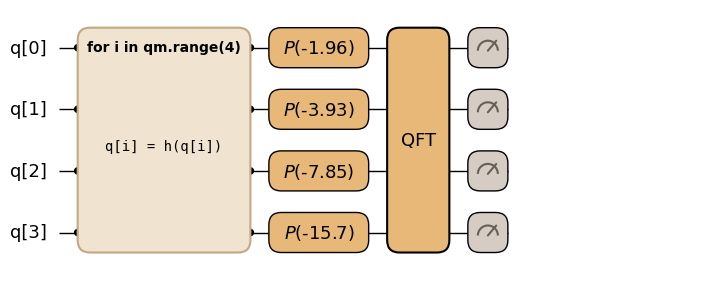

In [5]:
qft_frequency_estimator.draw()

`draw()`では、QFTが1つの演算として表示されます。トランスパイル後のQiskit回路を見たい場合は、`to_circuit`で変換します。

In [6]:
qiskit_circuit = transpiler.to_circuit(qft_frequency_estimator)
print(qiskit_circuit.draw())

     ┌───┐┌──────────┐┌──────┐┌─┐         
q_0: ┤ H ├┤ P(-5π/8) ├┤0     ├┤M├─────────
     ├───┤├──────────┤│      │└╥┘┌─┐      
q_1: ┤ H ├┤ P(-5π/4) ├┤1     ├─╫─┤M├──────
     ├───┤├──────────┤│  Qft │ ║ └╥┘┌─┐   
q_2: ┤ H ├┤ P(-5π/2) ├┤2     ├─╫──╫─┤M├───
     ├───┤└┬────────┬┘│      │ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─┤ P(-5π) ├─┤3     ├─╫──╫──╫─┤M├
     └───┘ └────────┘ └──────┘ ║  ║  ║ └╥┘
c: 4/══════════════════════════╩══╩══╩══╩═
                               0  1  2  3 


### 実行結果

次に、量子カーネルをローカルで実行し、測定された周波数インデックスのヒストグラムを描きます。下の変換では、上の状態準備に合わせて`q[0]`を最下位ビットとして扱います。

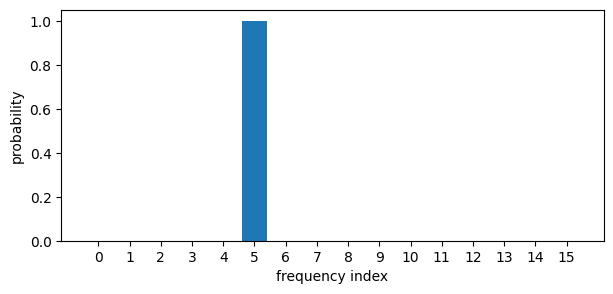

estimated frequency: 5


In [7]:
backend = AerSimulator(seed_simulator=1234, max_parallel_threads=1)
shots = 512
executable = transpiler.transpile(qft_frequency_estimator)
result = executable.sample(transpiler.executor(backend), shots=shots).result()

probabilities = np.zeros(dimension)
for outcome, count in result.results:
    frequency_index = sum(bit << idx for idx, bit in enumerate(outcome))
    probabilities[frequency_index] = count / shots

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(dimension), probabilities)
ax.set_xlabel("frequency index")
ax.set_ylabel("probability")
ax.set_xticks(range(dimension))
ax.set_ylim(0, 1.05)
plt.show()

estimated_frequency = int(np.argmax(probabilities))
print(f"estimated frequency: {estimated_frequency}")

assert result.shots == shots
assert sum(count for _, count in result.results) == shots
assert estimated_frequency == frequency
assert probabilities[frequency] > 0.95
assert all(
    isinstance(outcome, tuple) and len(outcome) == num_qubits
    for outcome, _ in result.results
)

## リソース推定

厳密なQFT回路では、次のゲートを使います。

- $n$個のアダマールゲート
- $\frac{n(n - 1)}{2}$個の制御付き位相回転
- $\left\lfloor n / 2 \right\rfloor$個のスワップ

したがって総ゲート数は$n + \frac{n(n - 1)}{2} + \left\lfloor n / 2 \right\rfloor$であり、$O(n^2)$で増えます。

それでは、Qamomileのリソース推定機能を使って確認してみましょう。
Qamomileでは、量子ビット数がバインドされていないシンボリックな量子カーネルに対して`estimate_resources()`を使うことで、量子ビット数に関する式としてスケーリングを確認することができます。

In [8]:
@qmc.qkernel
def qft_scaling(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")

    for j in qmc.range(n - 1, -1, -1):
        q[j] = qmc.h(q[j])

        for k in qmc.range(j - 1, -1, -1):
            angle = math.pi / (2 ** (j - k))
            q[j], q[k] = qmc.cp(q[j], q[k], angle)

    for j in qmc.range(n // 2):
        q[j], q[n - j - 1] = qmc.swap(q[j], q[n - j - 1])

    return q

In [9]:
symbolic_estimate = qft_scaling.estimate_resources().simplify()
print("量子ビット数:", symbolic_estimate.qubits)
print("総ゲート数:", symbolic_estimate.gates.total)
print("単一量子ビットゲート数:", symbolic_estimate.gates.single_qubit)
print("2量子ビットゲート数:", symbolic_estimate.gates.two_qubit)
print("回転ゲート数:", symbolic_estimate.gates.rotation_gates)
print("クリフォードゲート数:", symbolic_estimate.gates.clifford_gates)

assert "n" in str(symbolic_estimate.gates.total)
assert "j" not in str(symbolic_estimate.gates.total)
assert "k" not in str(symbolic_estimate.gates.total)

estimate_8 = symbolic_estimate.substitute(n=8)
assert estimate_8.qubits == 8
assert estimate_8.gates.total == 40
assert estimate_8.gates.single_qubit == 8
assert estimate_8.gates.two_qubit == 32
assert estimate_8.gates.rotation_gates == 28
assert estimate_8.gates.clifford_gates == 12

量子ビット数: n
総ゲート数: n**2/2 + n/2 + floor(n/2)
単一量子ビットゲート数: n
2量子ビットゲート数: n**2/2 - n/2 + floor(n/2)
回転ゲート数: n*(n - 1)/2
クリフォードゲート数: n + floor(n/2)


長さ$N$のベクトルを古典DFTで直接計算すると、$O(N^2)$回の演算が必要です。高速フーリエ変換（FFT）を使うと、これを$O(N\log N)$まで減らせます。一方、$N = 2^n$と書くと、厳密QFTは$O(n^2)=O((\log N)^2)$個のゲートで実装できます。したがって、直接計算する古典DFTと比べると、$N$に対して指数的に少ないゲートで同じ変換を状態に適用できます。ただし、測定だけで$N$個すべてのフーリエ係数を読み出せるわけではありません。QFTの利点は、変換後の振幅を後続の量子演算でそのまま使える場合に現れます。

## まとめ

このノートブックでは、古典DFTからQFTを導入し、4量子ビットの周波数推定の例を実装して、出力のサンプリングと計算量のスケーリングを確認しました。

- DFTは有限ベクトルを周波数に分解します。QFTは同じ変換を量子振幅に適用します。
- 4量子ビットの例では、単一周波数の位相パターンを準備し、QFTを適用して、サンプルされたヒストグラムから主要な周波数を推定します。
- Qamomileでは、`qamomile.circuit.stdlib.qft.qft`で`Vector[Qubit]`に直接QFTを適用できます。
- `draw()`、バックエンド実行、`estimate_resources()`により、同じQFT構造の回路表示、サンプル出力、計算量のスケーリングを確認できます。